Top gainer, 24h: 18    ZEC
Name: Ticker, dtype: str
Top loser, 24h: 35    WLFI
Name: Ticker, dtype: str
Total mcap: 2433447295566.0
Number of coins in a downtrend: 6


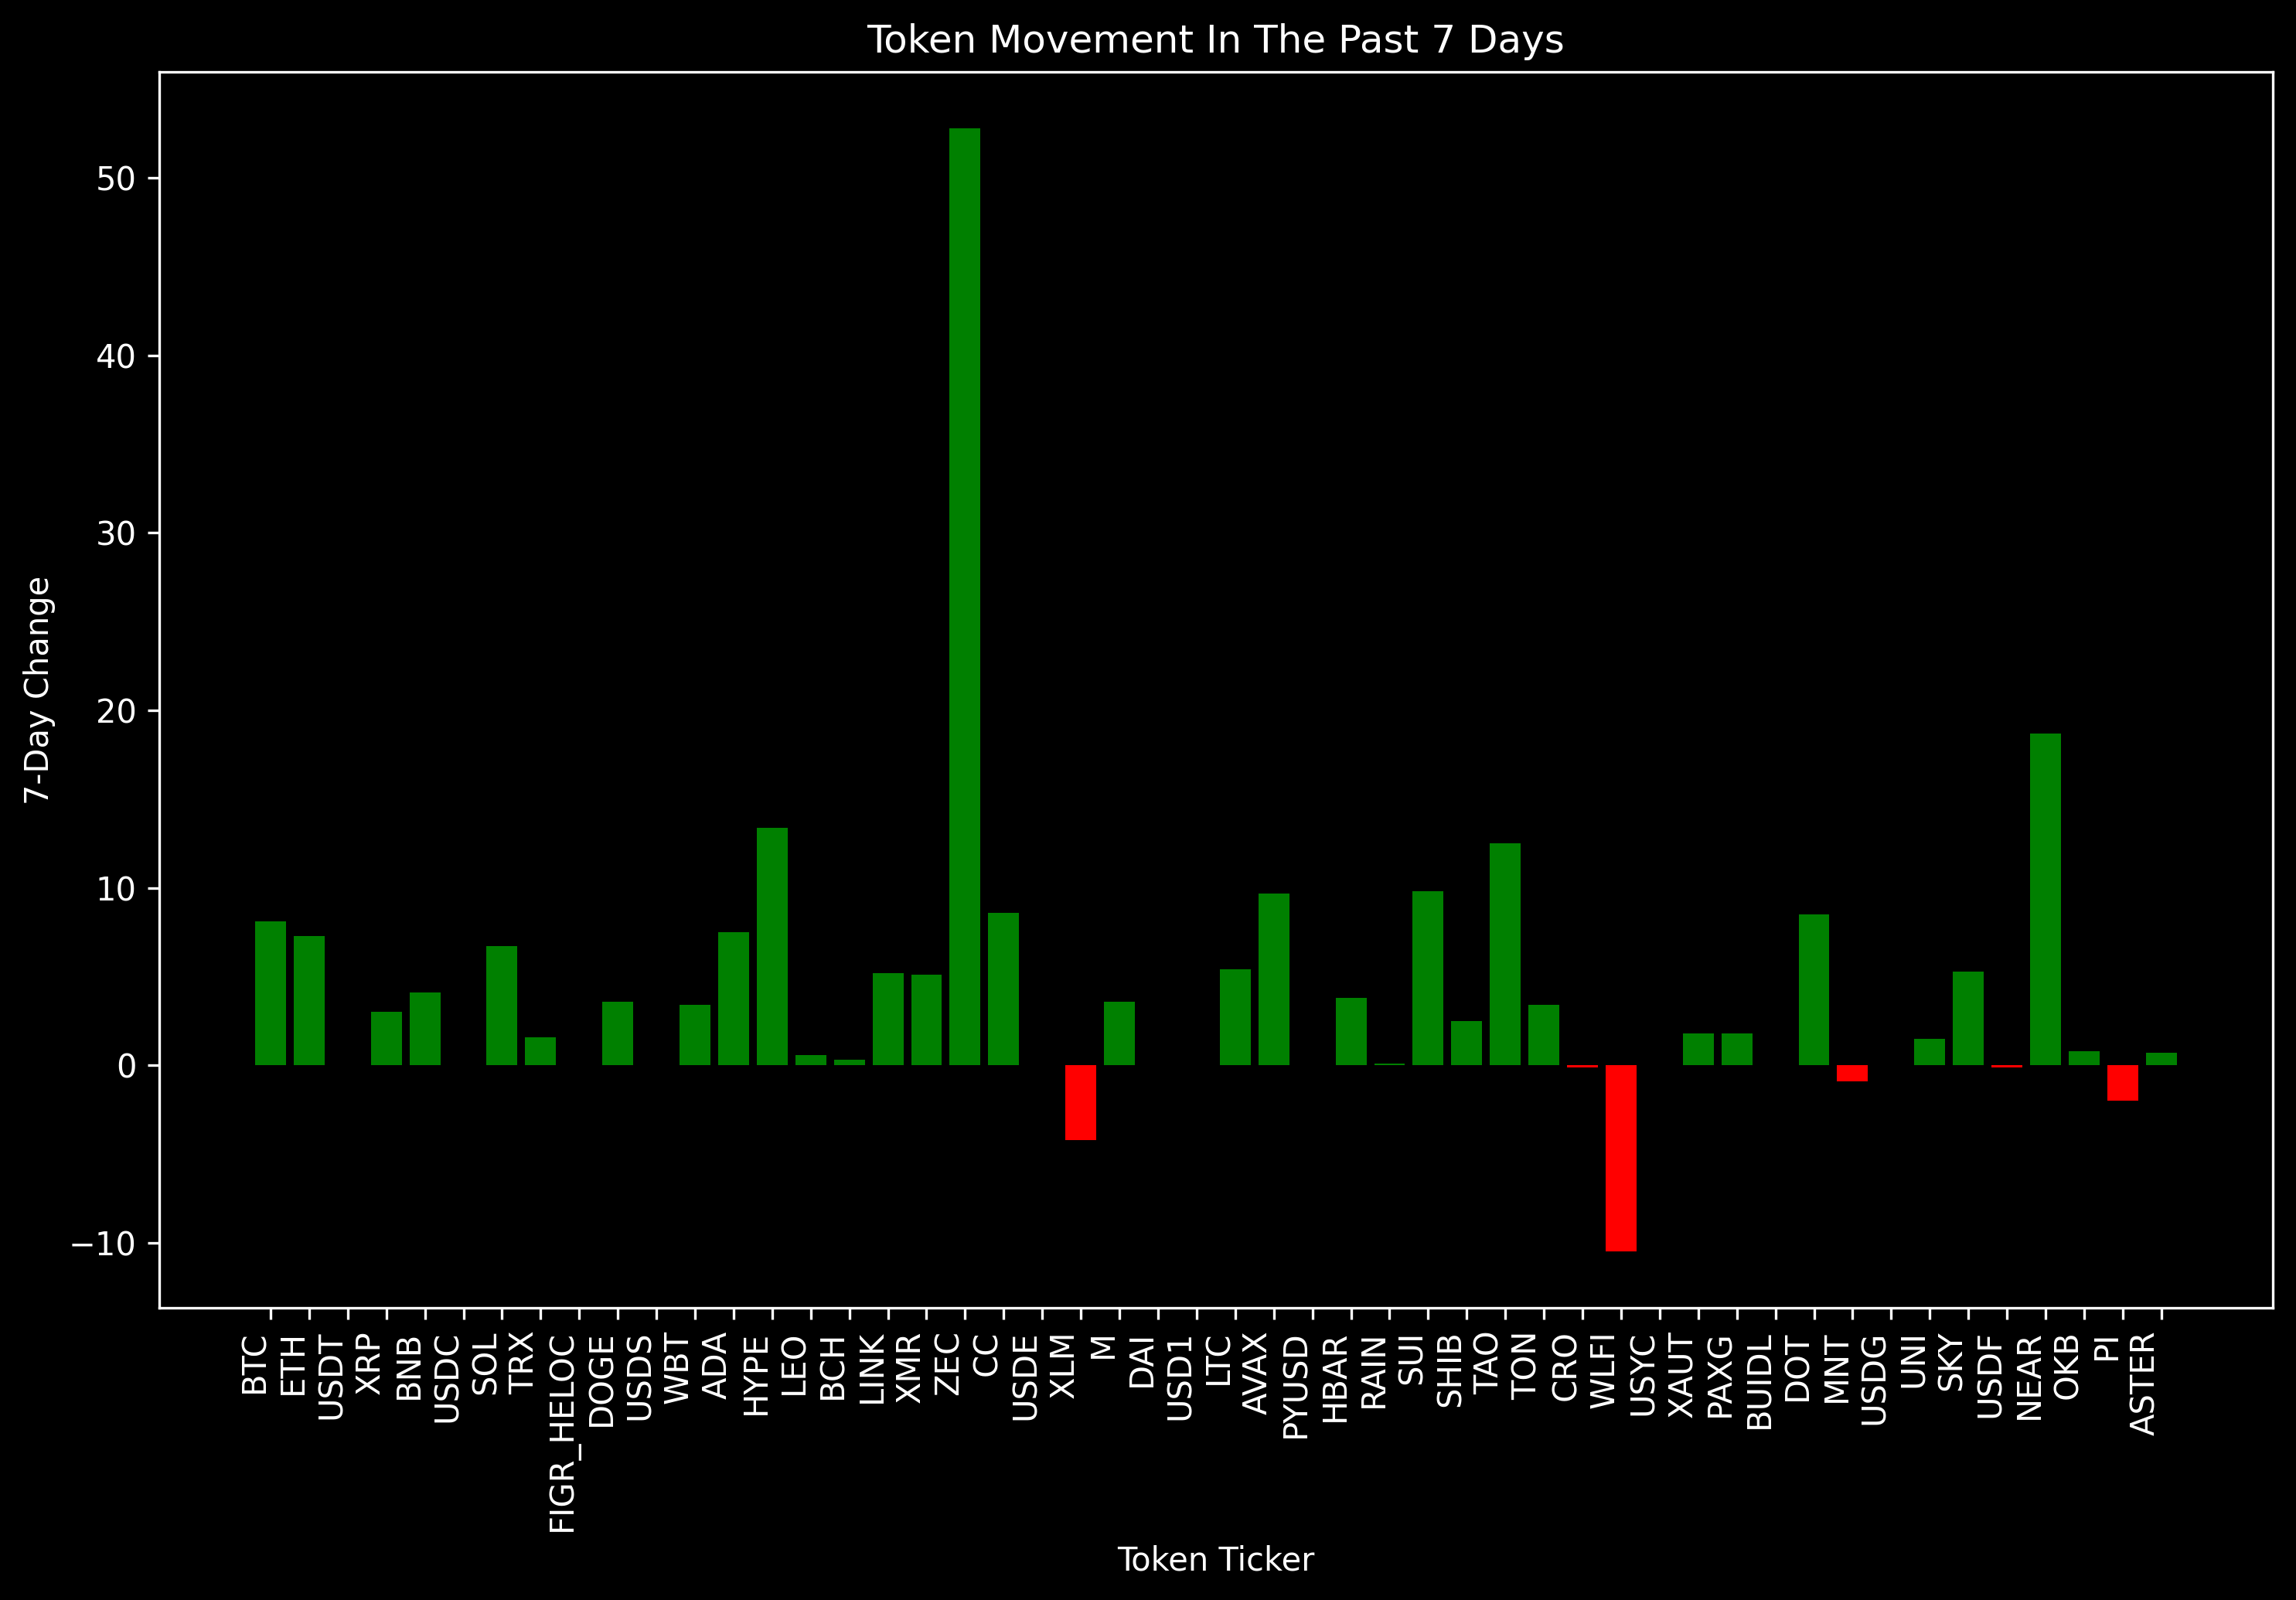

<Figure size 640x480 with 0 Axes>

In [5]:
from bs4 import BeautifulSoup
import requests
import csv
import pandas as pd
import matplotlib.pyplot as plt

response = requests.get("https://www.coingecko.com/")
coingecko = response.text
soup = BeautifulSoup(coingecko, "html.parser")

headers = ["Ticker", "Price", "1h", "24h", "7d", "24h volume", "Market Cap"]
prices = []
one_hour = []
twenty_four_hours = []
seven_days = []
volume_24 = []
mcap = []
token_tickers = []

# get the column titles
# thead = soup.find("thead")
# for col in thead.find_all("th"):
#     columns.append(col.get_text())

# get the table body
tbody = soup.find("tbody")
loop = 0
for i, row in enumerate(tbody.find_all("tr")):
    loop += 1
    # get the prices column
    price_cells = row.find("span", attrs={"data-price-target": "price"}).text.strip('$').replace(',', '')
    price = float(price_cells)
    prices.append(price)

    # get the 1h column
    one_h_span = row.find("span", attrs={"data-attr": "price_change_percentage_1h"})
    if one_h_span:
        one_h = float(one_h_span.text.strip('%'))
        down_one_h = one_h_span.find("i",
                                     class_="fas fa-fw fa-caret-down")  #puts a minus sign for field with negative change
        if down_one_h:
            if one_h > 0:
                one_h = float(f"-{one_h}")
    else:
        one_h = 0.0
    one_hour.append(one_h)

    # get 24h column
    tf_h_span = row.find("span", attrs={"data-attr": "price_change_percentage_24h"})
    if tf_h_span:
        tf_h = float(tf_h_span.text.strip('%'))
        down_tf_h = tf_h_span.find("i",
                                   class_="fas fa-fw fa-caret-down")  #puts a minus sign for field with negative change
        if down_tf_h:
            if tf_h > 0:
                tf_h = float(f"-{tf_h}")
    else:
        tf_h = 0.0
    twenty_four_hours.append(tf_h)

    # get 7d column
    sd_span = row.find("span", attrs={"data-attr": "price_change_percentage_7d"})
    if sd_span:
        sd = float(sd_span.text.strip('%'))
        down_sd = sd_span.find("i", class_="fas fa-fw fa-caret-down")  #puts a minus sign for field with negative change
        if down_sd:
            if sd > 0:
                sd = float(f"-{sd}")
    else:
        sd = 0.0
    seven_days.append(sd)

    # get 24 volume
    tf_h_vol = row.find_all("span", attrs={"data-price-target": "price"})[1].text.strip('$').replace(',', '')
    vol = float(tf_h_vol)
    volume_24.append(vol)

    # get mcap
    mcap_ = row.find_all("span", attrs={"data-price-target": "price"})[2].text.strip('$').replace(',', '')
    mcp = float(mcap_)
    mcap.append(mcp)
    if loop == 50:
        break

#get token tickers
loop = 0
token_tickers_ = soup.find_all(name="div",
                               class_="tw-block 2lg:tw-inline tw-text-xs tw-leading-4 tw-text-gray-500 dark:tw-text-moon-200 tw-font-medium")
loop = 0
for ticker in token_tickers_:
    loop += 1
    token_tickers.append(ticker.text.strip("\n").lstrip(" "))
    if loop == 50:
        break

columns = [token_tickers, prices, one_hour, twenty_four_hours, seven_days, volume_24, mcap]
rows_with_headers = dict(zip(headers, columns))
data = pd.DataFrame(rows_with_headers)
biggest_24h_gain = data["Ticker"][data["24h"] == max(data["24h"])]
print(f"Top gainer, 24h: {biggest_24h_gain}")
biggest_24h_loss = data["Ticker"][data["24h"] == min(data["24h"])]
print(f"Top loser, 24h: {biggest_24h_loss}")
total_mcap = sum(data["Market Cap"])
print(f"Total mcap: {total_mcap}")
nocd = 0
for c in data["7d"]:
    if c < 0:
        nocd += 1
print(f"Number of coins in a downtrend: {nocd}")
# print(data)
# data.to_csv("token_data.csv")
x = data["Ticker"]
y = data["7d"]

plt.figure(figsize=(10, 7), dpi=300)
plt.bar(x, y, color=["green" if v > 0 else "red" for v in y])
plt.xlabel("Token Ticker")
plt.ylabel("7-Day Change")
plt.title("Token Movement In The Past 7 Days")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.tight_layout()
plt.show()
plt.savefig("7_days_trend.png")


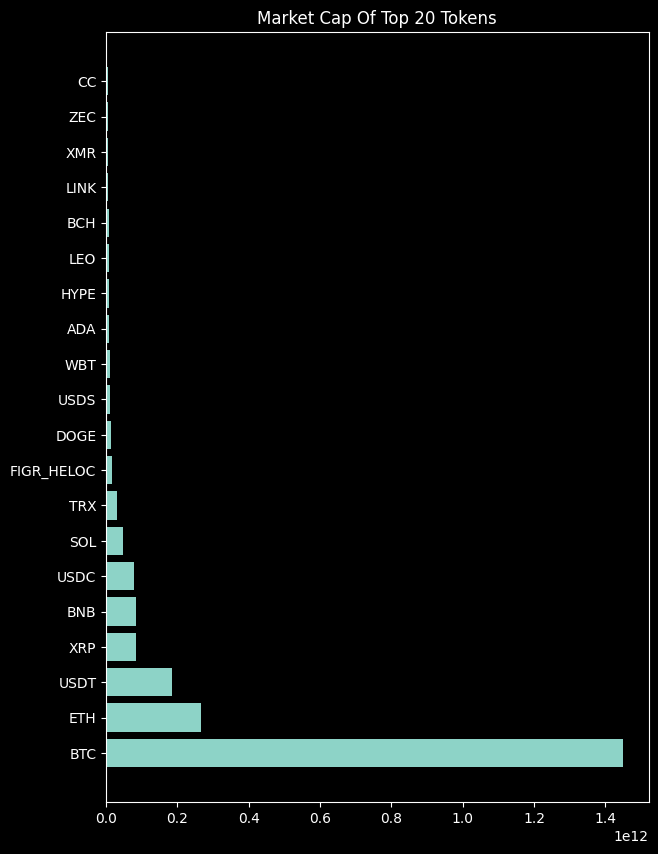

<Figure size 640x480 with 0 Axes>

In [6]:

plt.figure(figsize=(7, 10), dpi=100)
x = data["Ticker"][0:20]
y = data["Market Cap"][0:20]
plt.barh(x, y)
plt.title("Market Cap Of Top 20 Tokens")
plt.show()
plt.savefig("Top_20_MCap.png")





